Dataset loaded successfully!
Dataset shape: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Training samples: 120
Testing samples: 30

Model trained successfully!

--- MODEL EVALUATION ---
Accuracy: 93.33 %

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



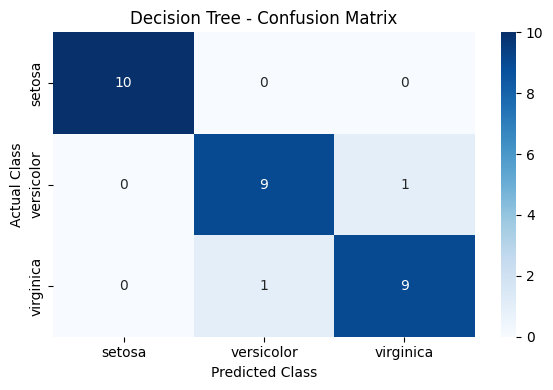

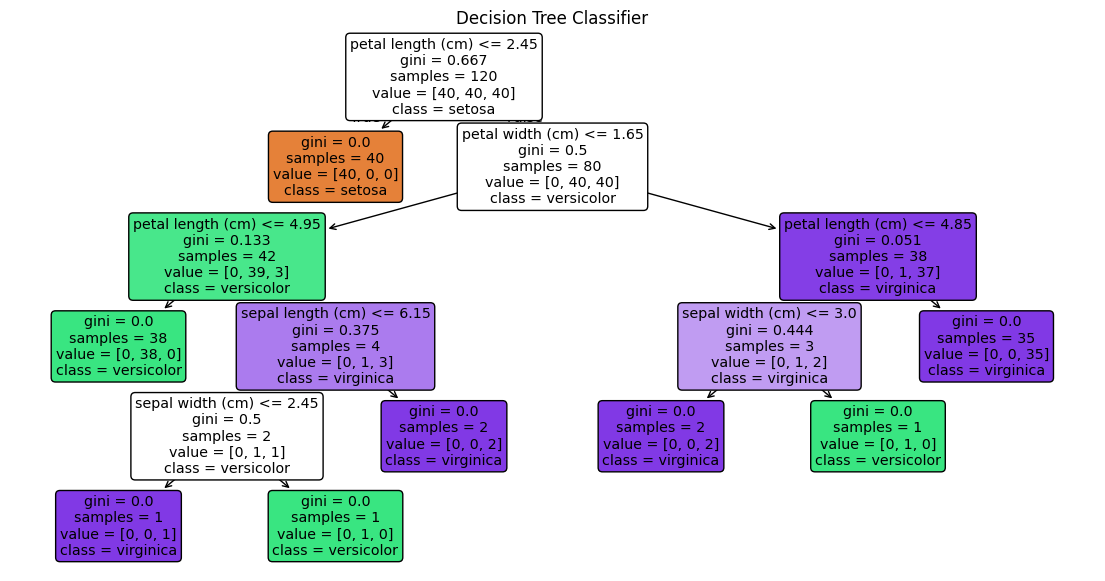


Feature Importance:


,Feature,Importance
2,petal length (cm),0.558568
3,petal width (cm),0.406015
1,sepal width (cm),0.029167
0,sepal length (cm),0.006250



--- CONCLUSION ---
The Decision Tree model achieved 93.33% accuracy.
The confusion matrix shows how many flowers were classified correctly or incorrectly.
Feature importance shows which measurements contributed most to the model.

Analysis completed successfully!


In [1]:

# FIRST MACHINE LEARNING CLASSIFIER
# Decision Tree Classifier using Scikit-learn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Load dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

print("Dataset loaded successfully!")
print("Dataset shape:", X.shape)
display(X.head())

# 2. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# 3. Train the Decision Tree model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

print("\nModel trained successfully!")

# 4. Make predictions
y_pred = model.predict(X_test)

# 5. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\n--- MODEL EVALUATION ---")
print("Accuracy:", round(accuracy * 100, 2), "%")
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# 6. Display confusion matrix as a chart
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

# 7. Visualize the decision tree
plt.figure(figsize=(14, 7))
plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True
)
plt.title("Decision Tree Classifier")
plt.show()

# 8. Feature importance
importance = pd.DataFrame({
    "Feature": iris.feature_names,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
display(importance)

# 9. Conclusion
print("\n--- CONCLUSION ---")
print(f"The Decision Tree model achieved {accuracy * 100:.2f}% accuracy.")
print("The confusion matrix shows how many flowers were classified correctly or incorrectly.")
print("Feature importance shows which measurements contributed most to the model.")

print("\nAnalysis completed successfully!")
